# Precificação Automática de Datasets On-Chain em InfoFi
## Análise Exploratória de Dados e Modelo de Valoração com XAI


| | |
|---|---|
| **Autor** | Adriana Ledezma |
| **Instituição** | Universidade de São Paulo (USP) |
| **Programa** | MBA de IA & Big Data |
| **Tema** | Precificação Automática de Informação On-chain e Valoração de Dados em InfoFi |
| **Tokens analisados** | AAVE · UNI · COMP · CRV · ETH |
| **Período** | Janeiro 2021 → Hoje |
| **Fonte de dados** | Kaggle + Yahoo Finance (atualização automática) |
| **Metodologia** | CRISP-DM · Random Forest · XAI/SHAP |

## 1. Background
O paradigma **Information Finance (InfoFi)** propõe tratar dados on-chain como ativos financeiros transacionáveis. Em redes blockchain públicas, informações como preços de tokens, liquidez de protocolos DeFi, volume de transações e indicadores de atividade de carteiras são gerads continuamente e possuem valor econômico real, mas ainda não existem mecanismos padronizados para precificá-las.

Este notebook implementa um **prótotipo de modelo de precificação automática de datasets on-chain**, utilizando dados históricos de 5 tokens DeFi como proxy de informação on-chain. O valor de cada dataset é operacionalizado como sua **capacidade preditiva sobre retornos futuros**, datasets cujos sinais informativos preveem melhor o comportamento do mercado são considerados mais valiosos.**texto en negrita**

A metodologia segue o framework **CRISP-DM** (*Cross Industry Standard Process for Data Mining*):

```
→ Entendimento do négocio
→ Entendimento do dados
→ Preparação dos dados
→ Modelagem
→ Avaliação
→ Implantação (Protótipo)
```

## Tokens analisados

| Token | Protocolo | Tipo | Relevância InfoFi |
|---|---|---|---|
| **ETH** | Ethereum | Layer 1 | Referência de mercado |
| **AAVE** | Aave | Lending DeFi | Dados de liquidez e empréstimos |
| **UNI** | Uniswap | DEX (AMM) | Dados de swap e liquidez |
| **COMP** | Compound | Lending DeFi | Taxas de juros on-chain |
| **CRV** | Curve Finance | DEX estável | Liquidez de stablecoins |

## 2. Objetivos

1. **Coletar** dados históricos de preço via fonte híbrida (Kaggle + Yahoo Finance)
2. **Pré-processar** os dados: limpeza, validação, tipos, nulos e duplicatas
3. **Explorar** distribuição de preços de fechamento e abertura por token
4. **Analisar** tendência de preços ao longo do tempo (2021–2026)
5.  **Calcular** distribuição de variações de preço diárias (price change)
6. **Mensurar** retorno diário percentual e sua distribuição
7. **Avaliar** volatilidade ao longo do tempo (rolling 20 dias)
8. **Computar** médias móveis SMA 50 e SMA 200 para identificar tendências
9. **Medir** drawdown por token (queda máxima desde o pico)
10. **Identificar** zonas de suporte e resistência
11. **Analisar** correlações entre features via heatmap
12. **Aplicar** Feature Selection com VIF (Variance Inflation Factor)
13. **Treinar** Random Forest + Regressão Linear com TimeSeriesSplit
14. **Explicar** previsões com SHAP (XAI)
15. **Ranquear** datasets por valor econômico (métrica InfoFi)

## 3. Importação de bibliotecas

In [37]:
# Manipulação de dados
import pandas as pd
import numpy as np
import warnings, os
from datetime import datetime
warnings.filterwarnings("ignore")

# Visualização
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Coleta de dados
import kagglehub
import yfinance as yf

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy import stats as scistats
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Explainability (XAI)
import shap

# Configurações visuais
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
sns.set_palette("husl")
print("✔ Todas as bibliotecas importadas com sucesso.")

✔ Todas as bibliotecas importadas com sucesso.


## 4. Coleta de dados
### Estratégia híbrida: Kaggle + Yahoo Finance
A coleta usa duas fontes:
*   **Kaggle:** CSVs históricos colocados na pasta `kaggle_data/`
*   **Yahoo Finance:** busca automaticamente os dias que faltam até hoje.

Se o arquivo Kaggle não existe, busca tudo via Yahoo desde 2021.

In [38]:
# Configurações
TOKENS      = ["AAVE", "UNI", "COMP", "CRV", "ETH"]
DATA_INICIO = "2021-01-01"
#DATA_HOJE   = datetime.today().strftime("%Y-%m-%d")
DATA_HOJE   = "2026-07-13"
N_FUTURO    = 7   # horizonte do future_return (dias)

PALETA = {"AAVE": "#987dfa", "UNI": "#f556ab",
          "COMP": "#3beb7b", "CRV": "#f7234d", "ETH": "#61a9fa"}
MAPA_TICKERS = {"AAVE": "AAVE-USD", "UNI": "UNI7083-USD",
                "COMP": "COMP5692-USD", "CRV": "CRV-USD", "ETH": "ETH-USD"}

# Download do Kaggle
path = kagglehub.dataset_download("svaningelgem/crypto-currencies-daily-prices")
print("Arquivos baixados em:", path)

os.makedirs("dados", exist_ok=True)
print(f"✔ Configurações OK | Data de hoje: {DATA_HOJE}")

Arquivos baixados em: C:\Users\Desktop\.cache\kagglehub\datasets\svaningelgem\crypto-currencies-daily-prices\versions\981
✔ Configurações OK | Data de hoje: 2026-07-13


In [39]:
# Funções de coleta
def _norm(df):
    """Padroniza DataFrame: colunas em minúsculo"""
    if df is None or df.empty:
        return None
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = [c.lower().strip() for c in df.columns]
    if hasattr(df.index, 'name') and df.index.name and 'date' in str(df.index.name).lower():
        df = df.reset_index()
    df.columns = [c.lower().strip() for c in df.columns]
    if "date" not in df.columns:
        return None
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()
    df = df[df["close"] > 0].dropna(subset=["close"]).copy()
    return df.sort_values("date").reset_index(drop=True)

def carregar_kaggle(token):
    """Carrega CSV do Kaggle se disponível"""
    caminho = os.path.join(path, f"{token}.csv")   # usa o path do kagglehub
    if not os.path.exists(caminho):
        return None
    df = pd.read_csv(caminho)
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()
    df = df[df["date"] >= pd.Timestamp(DATA_INICIO)]
    return df[df["close"] > 0].dropna(subset=["close"]).sort_values("date").reset_index(drop=True)

def buscar_yahoo(token, data_inicio, data_fim):
    """Busca dados via yfinance para o período informado"""
    ticker = MAPA_TICKERS.get(token, f"{token}-USD")
    try:
        df = yf.download(ticker, start=data_inicio, end=data_fim,
                         auto_adjust=True, progress=False)
        return _norm(df)
    except Exception as e:
        print(f"  ✘ Erro ao buscar {token}: {e}")
        return None

def coletar(token):
    """
    Estratégia híbrida:
      - COM Kaggle: histórico completo + dias faltantes via Yahoo
      - SEM Kaggle: tudo via Yahoo desde 2021
    """
    hoje = pd.Timestamp(DATA_HOJE)
    df_kaggle = carregar_kaggle(token)

    if df_kaggle is not None:
        ultimo = df_kaggle["date"].max()
        fonte = f"Kaggle ({len(df_kaggle)} dias até {ultimo.date()})"
        if (hoje - ultimo).days > 1:
            inicio = (ultimo + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
            df_yahoo = buscar_yahoo(token, inicio, DATA_HOJE)
            if df_yahoo is not None and not df_yahoo.empty:
                df_kaggle = (pd.concat([df_kaggle, df_yahoo], ignore_index=True)
                               .drop_duplicates("date", keep="last")
                               .sort_values("date").reset_index(drop=True))
                fonte += f" + Yahoo (+{len(df_yahoo)} dias novos)"
        df_kaggle = df_kaggle[df_kaggle["date"] >= pd.Timestamp(DATA_INICIO)].reset_index(drop=True)
        df_kaggle["ticker"] = token
        return df_kaggle, fonte

    df = buscar_yahoo(token, DATA_INICIO, DATA_HOJE)
    if df is not None:
        df["ticker"] = token
    fonte = f"Yahoo Finance ({len(df) if df is not None else 0} dias desde {DATA_INICIO})"
    return df, fonte

print("✔ Funções de coleta definidas.")

✔ Funções de coleta definidas.


In [40]:
# Executa a coleta
dados_raw = {}

for token in TOKENS:
    df, fonte = coletar(token)
    if df is not None and not df.empty:
        dados_raw[token] = df
        print(f"  [{token}] {fonte}")
    else:
        print(f"  [{token}] ✘ Sem dados")

print(f"\n✔ {len(dados_raw)}/{len(TOKENS)} tokens coletados.")

  [AAVE] Kaggle (1863 dias até 2026-03-27) + Yahoo (+107 dias novos)
  [UNI] Kaggle (1863 dias até 2026-03-27) + Yahoo (+107 dias novos)
  [COMP] Kaggle (1863 dias até 2026-03-27) + Yahoo (+107 dias novos)
  [CRV] Kaggle (1863 dias até 2026-03-27) + Yahoo (+107 dias novos)
  [ETH] Kaggle (1863 dias até 2026-03-27) + Yahoo (+107 dias novos)

✔ 5/5 tokens coletados.


In [41]:
# Preenche lacunas internas com Yahoo
print("Verificando lacunas internas:\n")

for token in TOKENS:
    df = dados_raw[token]
    todas = pd.date_range(DATA_INICIO, df["date"].max(), freq="D")
    faltantes = todas.difference(df["date"])

    if len(faltantes) == 0:
        print(f"  [{token}] ✔ sem lacunas")
        continue

    # Busca no Yahoo apenas o intervalo que falta (end é exclusivo, por isso +1 dia)
    inicio = faltantes.min().strftime("%Y-%m-%d")
    fim    = (faltantes.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    df_yahoo = buscar_yahoo(token, inicio, fim)

    if df_yahoo is None or df_yahoo.empty:
        print(f"  [{token}] ✘ Yahoo não retornou dados para {inicio} → {fim}")
        continue

    # Mantém só as datas realmente faltantes (não sobrescreve o Kaggle)
    df_yahoo = df_yahoo[df_yahoo["date"].isin(faltantes)].copy()
    df_yahoo["ticker"] = token

    dados_raw[token] = (pd.concat([df, df_yahoo], ignore_index=True)
                          .sort_values("date").reset_index(drop=True))
    print(f"  [{token}] +{len(df_yahoo)} dias preenchidos via Yahoo distribuídos entre ({inicio} → {fim})")

Verificando lacunas internas:

  [AAVE] +49 dias preenchidos via Yahoo distribuídos entre (2024-12-10 → 2025-10-19)
  [UNI] +49 dias preenchidos via Yahoo distribuídos entre (2024-12-10 → 2025-10-19)
  [COMP] +49 dias preenchidos via Yahoo distribuídos entre (2024-12-10 → 2025-10-19)
  [CRV] +49 dias preenchidos via Yahoo distribuídos entre (2024-12-10 → 2025-10-19)
  [ETH] +49 dias preenchidos via Yahoo distribuídos entre (2024-12-10 → 2025-10-19)


In [42]:
# verificação de lacunas
if len(df_yahoo) < len(faltantes):
    aun_faltan = faltantes.difference(df_yahoo["date"])
    print(f"  ⚠ [{token}] restam {len(aun_faltan)} vagas não preenchidas")

In [43]:
# Resumo
for token, df in dados_raw.items():
    print(f"  {token}: {len(df)} filas | {df['date'].min().date()} → {df['date'].max().date()} | duplicados: {df['date'].duplicated().sum()}")

# Primeiras linhas de cada token
for token in TOKENS:
    print(f"\n{'='*40}\n {token}\n{'='*40}")
    display(dados_raw[token].head())

  AAVE: 2019 filas | 2021-01-01 → 2026-07-12 | duplicados: 0
  UNI: 2019 filas | 2021-01-01 → 2026-07-12 | duplicados: 0
  COMP: 2019 filas | 2021-01-01 → 2026-07-12 | duplicados: 0
  CRV: 2019 filas | 2021-01-01 → 2026-07-12 | duplicados: 0
  ETH: 2019 filas | 2021-01-01 → 2026-07-12 | duplicados: 0

 AAVE


,ticker,date,open,high,low,close,volume
0,AAVE,2021-01-01,88.35,90.86,84.93,90.77,NaN
1,AAVE,2021-01-02,90.77,91.88,82.52,85.79,NaN
2,AAVE,2021-01-03,85.79,94.91,81.53,93.59,NaN
3,AAVE,2021-01-04,93.59,115.38,86.27,113.89,NaN
4,AAVE,2021-01-05,113.89,123.55,98.71,119.56,NaN



 UNI


,ticker,date,open,high,low,close,volume
0,UNI,2021-01-01,5.159,5.276,4.623,4.744,NaN
1,UNI,2021-01-02,4.744,5.178,4.489,4.861,NaN
2,UNI,2021-01-03,4.861,5.631,4.678,5.489,NaN
3,UNI,2021-01-04,5.489,6.184,4.970,5.423,NaN
4,UNI,2021-01-05,5.423,6.563,5.209,6.263,NaN



 COMP


,ticker,date,open,high,low,close,volume
0,COMP,2021-01-01,150.65,155.18,140.39,144.19,NaN
1,COMP,2021-01-02,144.15,147.89,136.80,138.53,NaN
2,COMP,2021-01-03,138.47,151.52,134.90,148.66,NaN
3,COMP,2021-01-04,148.66,162.18,137.87,146.99,NaN
4,COMP,2021-01-05,146.89,166.02,145.97,164.49,NaN



 CRV


,ticker,date,open,high,low,close,volume
0,CRV,2021-01-01,0.6278,0.6761,0.6073,0.6225,NaN
1,CRV,2021-01-02,0.6225,0.6244,0.5663,0.6141,NaN
2,CRV,2021-01-03,0.6141,0.6940,0.5873,0.6776,NaN
3,CRV,2021-01-04,0.6776,0.7311,0.5864,0.6775,NaN
4,CRV,2021-01-05,0.6775,0.7279,0.6266,0.6887,NaN



 ETH


,ticker,date,open,high,low,close,volume
0,ETH,2021-01-01,741.60,749.70,717.48,730.81,NaN
1,ETH,2021-01-02,730.86,788.27,716.78,772.68,NaN
2,ETH,2021-01-03,772.70,996.63,765.65,993.13,NaN
3,ETH,2021-01-04,992.82,1163.36,894.10,1014.43,NaN
4,ETH,2021-01-05,1012.80,1132.90,975.77,1112.74,NaN


In [44]:
# Verificação de nulos
print("Valores nulos por token:\n")
for token, df in dados_raw.items():
    n = df.isnull().sum().sum()
    print(f"  [{token}] {'✔ Sem nulos' if n == 0 else f'⚠ {n} nulos'}")

Valores nulos por token:

  [AAVE] ⚠ 1863 nulos
  [UNI] ⚠ 1863 nulos
  [COMP] ⚠ 1863 nulos
  [CRV] ⚠ 1863 nulos
  [ETH] ⚠ 1863 nulos


In [45]:
# Volume completo via Yahoo + verificação de nulos
print("Buscando volume completo no Yahoo:\n")

for token in TOKENS:
    df_vol = buscar_yahoo(token, DATA_INICIO, DATA_HOJE)
    if df_vol is None or "volume" not in df_vol.columns:
        print(f"  [{token}] ✘ Sem volume no Yahoo — mantido como está")
        continue

    # Descarta o volume incompleto e une o do Yahoo por data
    df = dados_raw[token].drop(columns=["volume"], errors="ignore")
    df = df.merge(df_vol[["date", "volume"]], on="date", how="left")

    # Preenche lacunas apenas com o passado (forward fill)
    n_antes = df["volume"].isnull().sum()
    df["volume"] = df["volume"].ffill()
    n_depois = df["volume"].isnull().sum()

    dados_raw[token] = df
    print(f"  [{token}] volume unido | NaN: {n_antes} → {n_depois} após ffill")

# Verificação final de nulos 
print("\nValores nulos por token:\n")
for token, df in dados_raw.items():
    n = df.isnull().sum().sum()
    print(f"  [{token}] {'✔ Sem nulos' if n == 0 else f'⚠ {n} nulos'}")

Buscando volume completo no Yahoo:

  [AAVE] volume unido | NaN: 0 → 0 após ffill
  [UNI] volume unido | NaN: 0 → 0 após ffill
  [COMP] volume unido | NaN: 0 → 0 após ffill
  [CRV] volume unido | NaN: 0 → 0 após ffill
  [ETH] volume unido | NaN: 0 → 0 após ffill

Valores nulos por token:

  [AAVE] ✔ Sem nulos
  [UNI] ✔ Sem nulos
  [COMP] ✔ Sem nulos
  [CRV] ✔ Sem nulos
  [ETH] ✔ Sem nulos


## 4.2 Dataset Unificado
Em vez de tranalhar com um DataFrame separado por token, criamos um único dataset com todos os tokens concatenados. A coluna `ticker` identifica o token de cada observação, asim quando quisermos fazer análise por token basta filtrar por `ticker`.

Estrutura final: `date · ticker · open · high · low · close · volume`

In [46]:
# Garante que cada df tem a coluna ticker preenchida
for token, df in dados_raw.items():
    dados_raw[token]["ticker"] = token

# Seleciona apenas as colunas base OHLCV (sem features)
cols_base = ["date", "ticker", "open", "high", "low", "close", "volume"]

df_unificado = pd.concat(
    [df[[c for c in cols_base if c in df.columns]] for df in dados_raw.values()],
    ignore_index=True
).sort_values(["ticker", "date"]).reset_index(drop=True)

# Garante tipos corretos
df_unificado["date"]   = pd.to_datetime(df_unificado["date"])
df_unificado["volume"] = df_unificado["volume"].astype(float)

print(f"✔ Dataset unificado criado!")
print(f"  Shape:   {df_unificado.shape}")
print(f"  Colunas: {list(df_unificado.columns)}")
print(f"  Tickers: {df_unificado['ticker'].unique().tolist()}")
print(f"  Período: {df_unificado['date'].min().date()} → {df_unificado['date'].max().date()}")
print()
print("Observações por token:")
display(df_unificado.groupby("ticker").agg(
    observacoes=("date","count"),
    inicio=("date","min"),
    fim=("date","max"),
    preco_medio=("close","mean")
).round(2))

✔ Dataset unificado criado!
  Shape:   (10095, 7)
  Colunas: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
  Tickers: ['AAVE', 'COMP', 'CRV', 'ETH', 'UNI']
  Período: 2021-01-01 → 2026-07-12

Observações por token:


,observacoes,inicio,fim,preco_medio
ticker,,,,
AAVE,2019,2021-01-01,2026-07-12,170.24
COMP,2019,2021-01-01,2026-07-12,113.70
CRV,2019,2021-01-01,2026-07-12,1.15
ETH,2019,2021-01-01,2026-07-12,2502.25
UNI,2019,2021-01-01,2026-07-12,10.10


In [47]:
print("Primeiras linhas do Dataset Unificado")
display(df_unificado.head(10))
print("\nÚltimas linhas do Dataset Unificado")
display(df_unificado.tail(10))

Primeiras linhas do Dataset Unificado


,date,ticker,open,high,low,close,volume
0,2021-01-01,AAVE,88.35,90.86,84.93,90.77,202515779.0
1,2021-01-02,AAVE,90.77,91.88,82.52,85.79,221843920.0
2,2021-01-03,AAVE,85.79,94.91,81.53,93.59,298884107.0
3,2021-01-04,AAVE,93.59,115.38,86.27,113.89,619262373.0
4,2021-01-05,AAVE,113.89,123.55,98.71,119.56,573305329.0
5,2021-01-06,AAVE,119.56,120.11,108.21,115.06,392901334.0
6,2021-01-07,AAVE,115.06,128.80,107.89,114.73,467716121.0
7,2021-01-08,AAVE,114.73,118.77,100.52,110.50,501393572.0
8,2021-01-09,AAVE,110.50,119.60,106.50,118.13,337620868.0
9,2021-01-10,AAVE,118.13,135.42,111.57,126.95,512402603.0



Últimas linhas do Dataset Unificado


,date,ticker,open,high,low,close,volume
10085,2026-07-03,UNI,3.174648,3.298525,3.155611,3.208554,168205477.0
10086,2026-07-04,UNI,3.208529,3.258978,3.171125,3.215278,102598125.0
10087,2026-07-05,UNI,3.215278,3.215278,3.100298,3.171475,104726586.0
10088,2026-07-06,UNI,3.171521,3.242807,3.074671,3.176156,134853195.0
10089,2026-07-07,UNI,3.176154,3.302818,3.109308,3.189890,139351166.0
10090,2026-07-08,UNI,3.189841,3.366854,3.144990,3.277997,295157611.0
10091,2026-07-09,UNI,3.278000,3.430047,3.248682,3.396784,213912734.0
10092,2026-07-10,UNI,3.396547,3.688526,3.377839,3.525931,247269924.0
10093,2026-07-11,UNI,3.525609,3.827825,3.465561,3.663877,225624500.0
10094,2026-07-12,UNI,3.663923,3.721939,3.583945,3.591296,152710832.0


## 5. Pré-processamento dos Dados
### 5.1 Inspeção e Limpeza

In [48]:
# Estrutura dos dados por token
for token, df in dados_raw.items():
    print(f"  {token}  ({len(df)} linhas × {len(df.columns)} colunas)")
    print(df.dtypes)

  AAVE  (2019 linhas × 7 colunas)
ticker            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object
  UNI  (2019 linhas × 7 colunas)
ticker            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object
  COMP  (2019 linhas × 7 colunas)
ticker            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object
  CRV  (2019 linhas × 7 colunas)
ticker            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object
  ETH  (2019 linhas × 7 colunas)
ticker            object
date      datetime64[ns]
open             float64
hi

In [49]:
# Verificação de nulos
print("Valores nulos por token:\n")
for token, df in dados_raw.items():
    n = df.isnull().sum().sum()
    print(f"  [{token}] {'✔ Sem nulos' if n == 0 else f'⚠ {n} nulos'}")

Valores nulos por token:

  [AAVE] ✔ Sem nulos
  [UNI] ✔ Sem nulos
  [COMP] ✔ Sem nulos
  [CRV] ✔ Sem nulos
  [ETH] ✔ Sem nulos


In [50]:
# Verificação de duplicatas
print("Duplicatas de data por token:\n")
for token, df in dados_raw.items():
    n = df.duplicated(subset="date").sum()
    print(f"  [{token}] {'✔ Sem duplicatas' if n == 0 else f'⚠ {n} duplicatas'}")

Duplicatas de data por token:

  [AAVE] ✔ Sem duplicatas
  [UNI] ✔ Sem duplicatas
  [COMP] ✔ Sem duplicatas
  [CRV] ✔ Sem duplicatas
  [ETH] ✔ Sem duplicatas


### 5.2 Estatísticas Descritivas

In [51]:
for token, df in dados_raw.items():
    cols = [c for c in ["open","high","low","close","volume"] if c in df.columns]
    print(f"\n{'='*55}  {token}")
    display(df[cols].describe().round(2))


=======================================================  AAVE


,open,high,low,close,volume
count,2019.00,2019.00,2019.00,2019.00,2.019000e+03
mean,170.24,178.05,162.28,170.24,2.951977e+08
std,108.11,114.83,101.55,108.10,2.793657e+08
min,48.12,51.18,45.62,48.22,2.323027e+07
25%,85.60,88.82,82.77,85.58,1.172616e+08
50%,126.55,130.96,120.85,126.46,2.276853e+08
75%,253.06,263.65,240.74,253.15,3.832787e+08
max,629.04,667.83,563.16,630.07,2.838573e+09



=======================================================  UNI


,open,high,low,close,volume
count,2019.00,2019.00,2019.00,2019.00,2.019000e+03
mean,10.10,10.55,9.65,10.10,3.404694e+08
std,7.62,8.04,7.19,7.62,4.810083e+08
min,2.40,2.48,2.33,2.40,2.359653e+07
25%,5.59,5.84,5.36,5.58,1.171376e+08
50%,6.91,7.18,6.67,6.91,2.025721e+08
75%,11.01,11.53,10.48,11.02,3.688026e+08
max,43.11,44.98,41.59,43.11,6.372858e+09



=======================================================  COMP


,open,high,low,close,volume
count,2019.00,2019.00,2019.00,2019.00,2.019000e+03
mean,113.77,119.31,107.78,113.70,9.062769e+07
std,143.39,151.69,134.20,143.41,1.108307e+08
min,15.18,15.76,14.68,15.18,6.540356e+06
25%,41.10,42.48,39.85,41.05,2.831622e+07
50%,51.44,53.34,49.52,51.39,4.833416e+07
75%,98.14,103.06,90.20,96.86,1.058400e+08
max,861.92,912.64,810.00,861.92,1.146127e+09



=======================================================  CRV


,open,high,low,close,volume
count,2019.00,2019.00,2019.00,2019.00,2.019000e+03
mean,1.15,1.21,1.08,1.15,1.666204e+08
std,1.10,1.17,1.02,1.10,1.784451e+08
min,0.18,0.19,0.17,0.18,1.362674e+07
25%,0.45,0.47,0.43,0.45,5.642917e+07
50%,0.71,0.75,0.67,0.71,1.078668e+08
75%,1.33,1.42,1.23,1.33,2.034151e+08
max,6.32,6.80,6.06,6.32,1.619119e+09



=======================================================  ETH


,open,high,low,close,volume
count,2019.00,2019.00,2019.00,2019.00,2.019000e+03
mean,2501.75,2569.58,2427.06,2502.25,1.949791e+10
std,884.82,906.68,858.90,883.99,1.267495e+10
min,730.86,749.70,716.78,730.81,2.081626e+09
25%,1795.41,1832.28,1746.14,1795.38,1.042925e+10
50%,2350.85,2415.53,2280.81,2350.80,1.666287e+10
75%,3155.12,3251.27,3069.64,3155.24,2.455616e+10
max,4850.55,4954.53,4720.67,4851.54,9.773662e+10


## 6. Análise Exploratória de Dados (EDA)

### 6.1 Tendência de preços ao longo do tempo

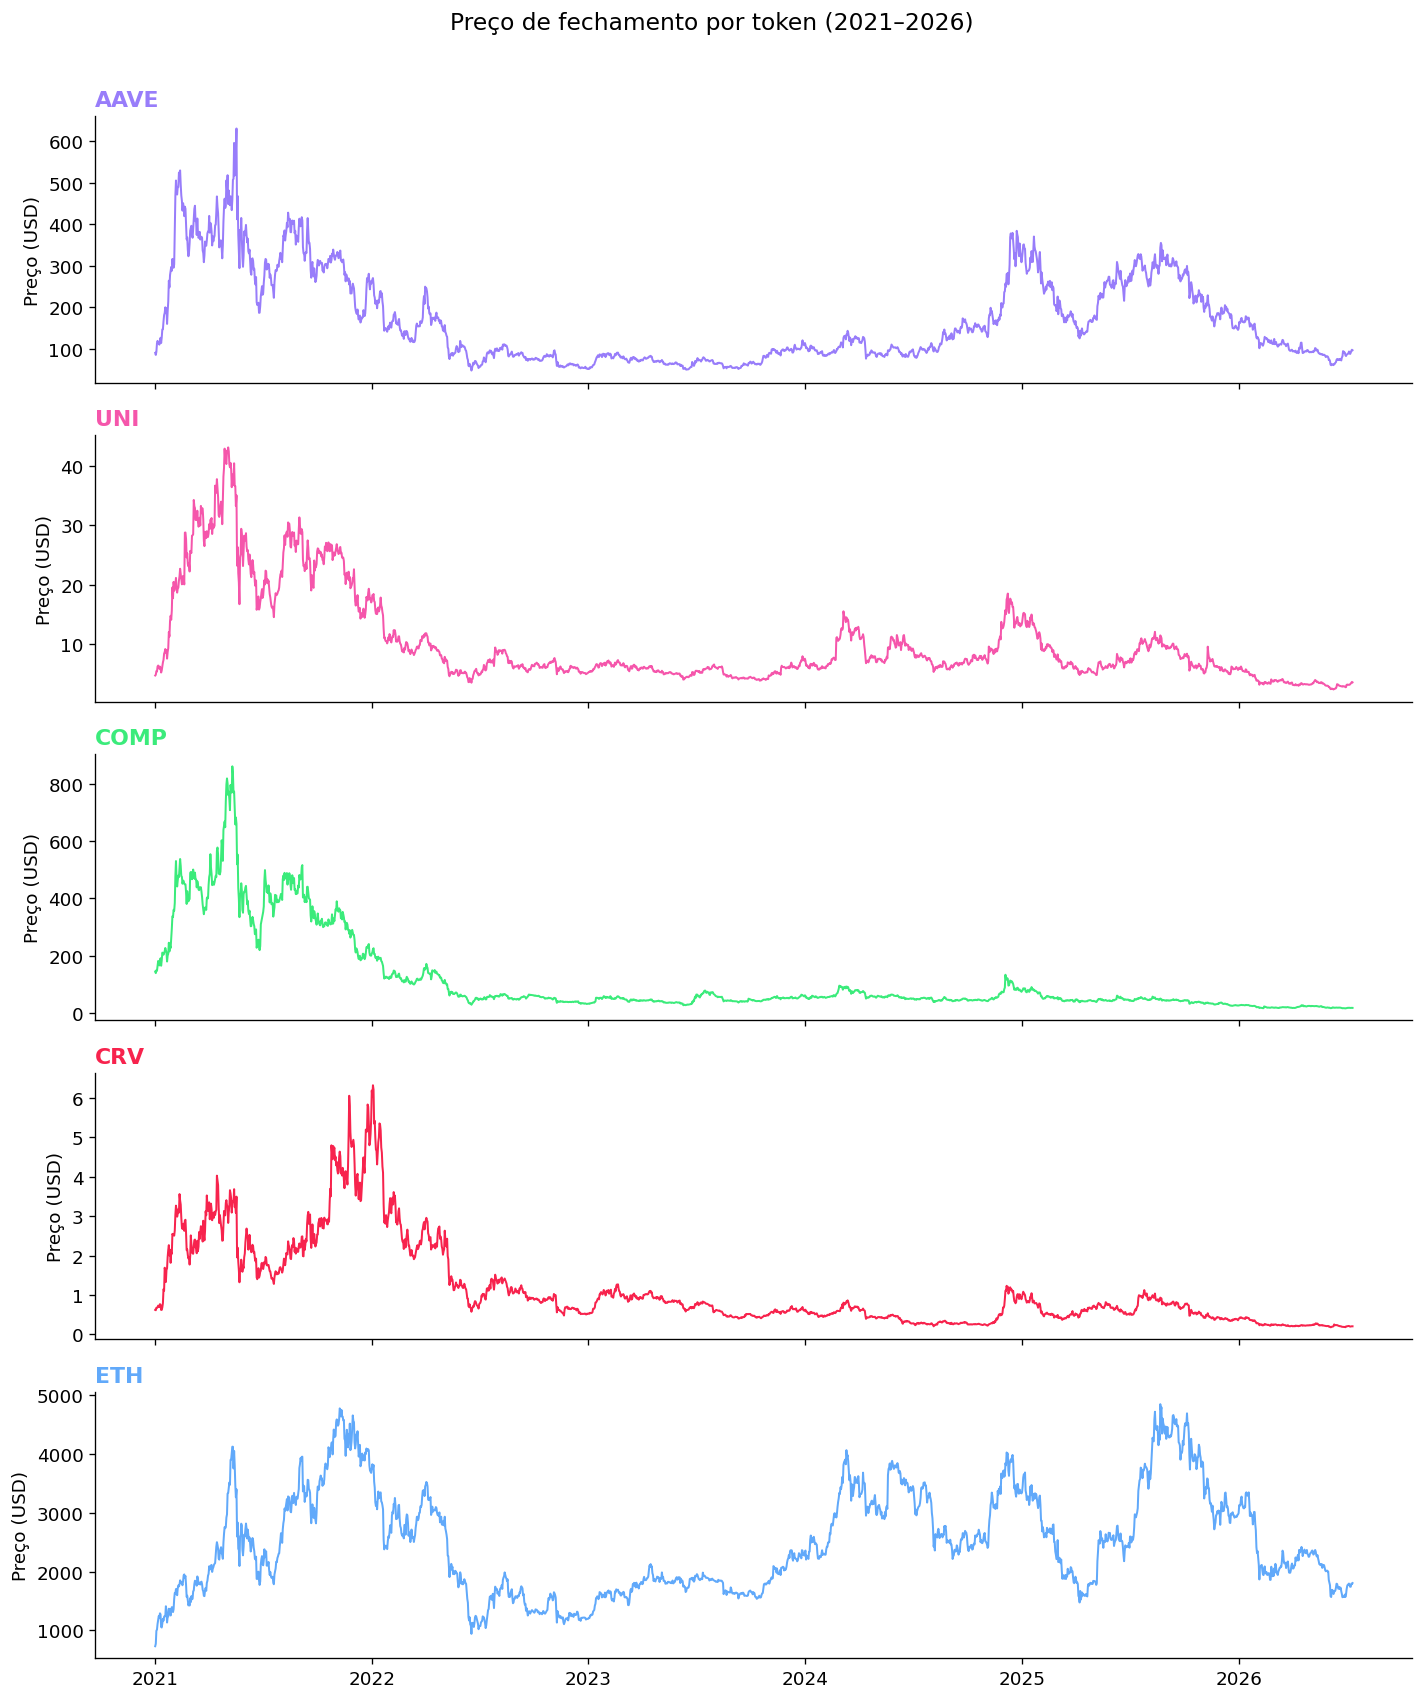

In [52]:
fig, axes = plt.subplots(len(TOKENS), 1, figsize=(12, 14), sharex=True)

for ax, token in zip(axes, TOKENS):
    d = df_unificado[df_unificado["ticker"] == token]
    ax.plot(d["date"], d["close"], color=PALETA[token], lw=1.2)
    ax.set_title(token, loc="left", fontweight="bold", color=PALETA[token])
    ax.set_ylabel("Preço (USD)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Preço de fechamento por token (2021–2026)", y=1.01, fontsize=14)
plt.tight_layout()

def salvar_fig(fig, nome):
    fig.savefig(os.path.join("dados", f"{nome}.png"), dpi=300, bbox_inches="tight")
    
salvar_fig(fig, "tendencia_precos")
plt.show()

### 6.2 Performance normalizada (base 100)

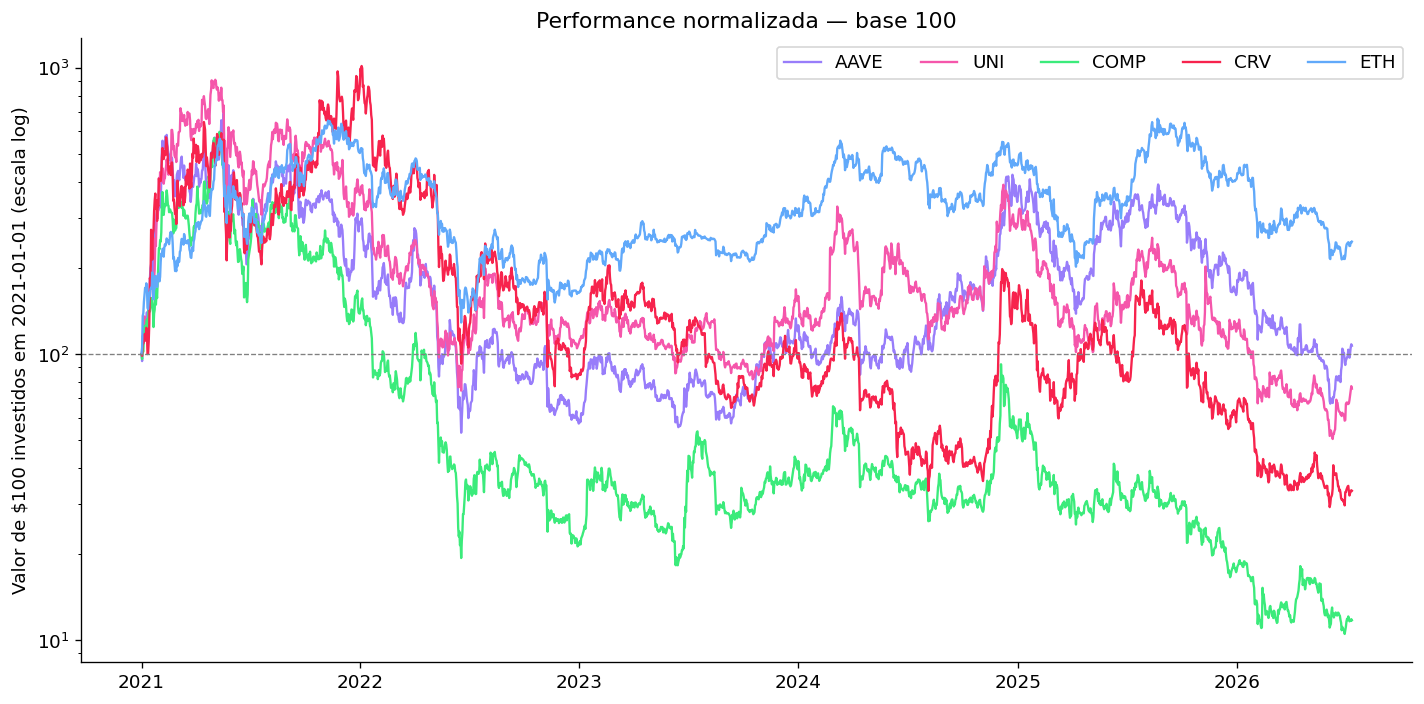

Valor final de $100 investidos em 2021-01-01:
ticker
ETH     247.1
AAVE    106.9
UNI      75.7
CRV      33.3
COMP     11.7


In [53]:
# Pivot: filas = datas, colunas = tokens, valores = close
precos = df_unificado.pivot(index="date", columns="ticker", values="close")

# Divide cada coluna pelo seu primeiro valor e multiplica por 100
norm = precos / precos.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
for token in TOKENS:
    ax.plot(norm.index, norm[token], color=PALETA[token], lw=1.4, label=token)

ax.axhline(100, color="gray", ls="--", lw=0.8)   # linha do investimento inicial
ax.set_yscale("log")                              # escala log: quedas e altas simétricas
ax.set_ylabel("Valor de $100 investidos em 2021-01-01 (escala log)")
ax.legend(ncol=5, loc="upper right")
ax.set_title("Performance normalizada — base 100")
plt.tight_layout()
salvar_fig(fig, "perfom_normalizada.png")
plt.show()

# Tabela resumo: valor final de cada token
print("Valor final de $100 investidos em 2021-01-01:")
print(norm.iloc[-1].round(1).sort_values(ascending=False).to_string())

### 6.3 Distribuição de retornos diários (%)

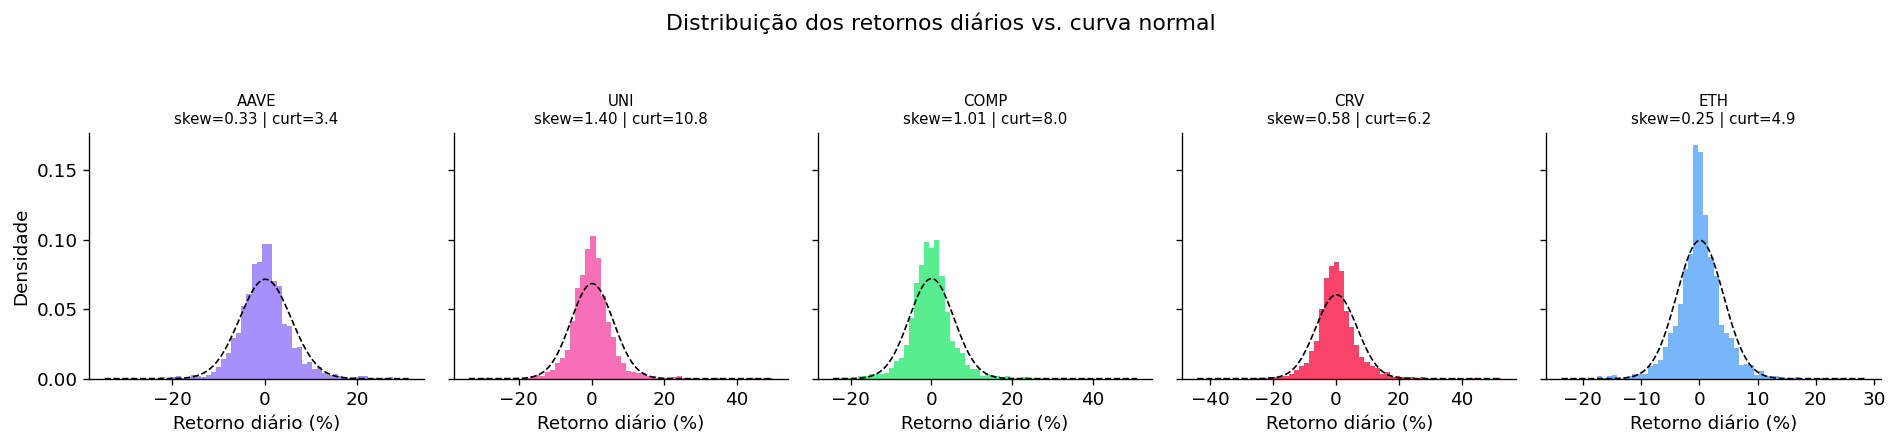

        mean   std    min    max  skew
ticker                                
AAVE    0.16  5.58 -34.63  31.13  0.33
COMP    0.04  5.54 -24.38  51.00  1.01
CRV     0.16  6.61 -44.08  52.57  0.58
ETH     0.12  4.01 -23.66  28.53  0.25
UNI     0.15  5.83 -33.77  49.87  1.40


In [54]:
# Retornos diários (dentro de cada token)
ret = df_unificado.copy()
ret["return_1d"] = ret.groupby("ticker")["close"].pct_change() * 100
ret = ret.dropna(subset=["return_1d"])

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)

for ax, token in zip(axes, TOKENS):
    r = ret.loc[ret["ticker"] == token, "return_1d"]
    ax.hist(r, bins=60, color=PALETA[token], alpha=0.85, density=True)

    # Curva normal com mesma média e desvio, para comparação
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, scistats.norm.pdf(x, r.mean(), r.std()), "k--", lw=1)

    ax.set_title(f"{token}\nskew={r.skew():.2f} | curt={r.kurtosis():.1f}", fontsize=9)
    ax.set_xlabel("Retorno diário (%)")

axes[0].set_ylabel("Densidade")
fig.suptitle("Distribuição dos retornos diários vs. curva normal", y=1.05)
plt.tight_layout()
salvar_fig(fig, "distribuicao_retornos")
plt.show()

# Estatísticas resumo
print(ret.groupby("ticker")["return_1d"]
        .agg(["mean", "std", "min", "max", "skew"])
        .round(2).to_string())

### 6.4 Volatilidade rolling e Drawdown

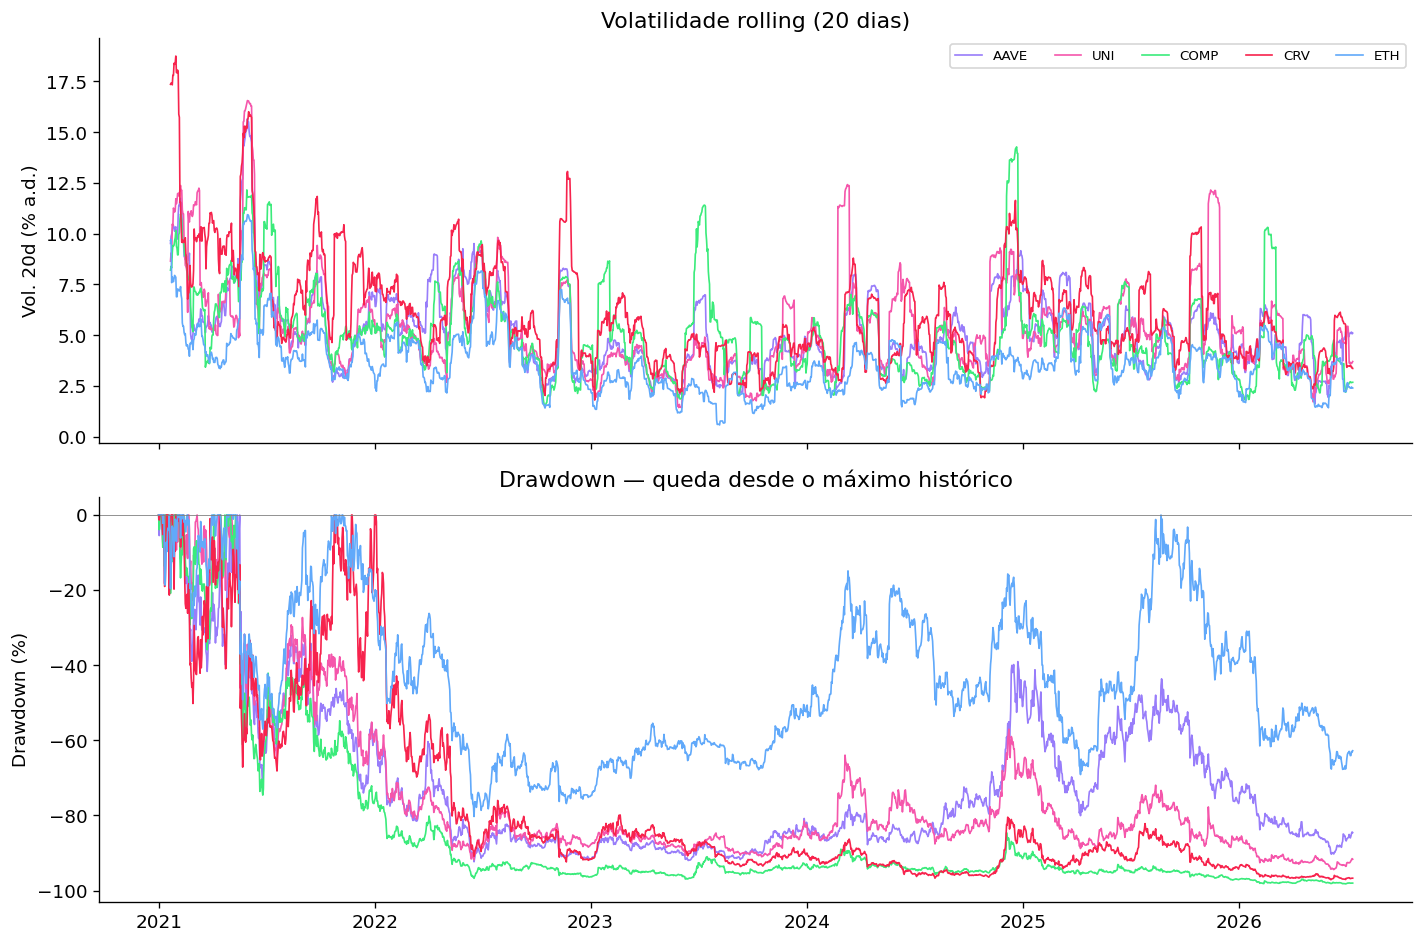

Máximo drawdown por token:
ticker
COMP   -98.2
CRV    -97.1
UNI    -94.4
AAVE   -92.3
ETH    -80.3


In [55]:
eda = df_unificado.copy()
g = eda.groupby("ticker")

# Volatilidade: desvio padrão dos retornos em janela de 20 dias
eda["return_1d"] = g["close"].pct_change() * 100
eda["vol_20d"] = eda.groupby("ticker")["return_1d"].transform(lambda s: s.rolling(20).std())

# Drawdown: queda % em relação ao máximo histórico até aquele dia
eda["cummax"]   = g["close"].cummax()
eda["drawdown"] = (eda["close"] / eda["cummax"] - 1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for token in TOKENS:
    d = eda[eda["ticker"] == token]
    ax1.plot(d["date"], d["vol_20d"], color=PALETA[token], lw=1, label=token)
    ax2.plot(d["date"], d["drawdown"], color=PALETA[token], lw=1, label=token)

ax1.set_ylabel("Vol. 20d (% a.d.)")
ax1.set_title("Volatilidade rolling (20 dias)")
ax1.legend(ncol=5, fontsize=8)

ax2.set_ylabel("Drawdown (%)")
ax2.set_title("Drawdown — queda desde o máximo histórico")
ax2.axhline(0, color="gray", lw=0.5)

plt.tight_layout()
salvar_fig(fig, "volatilidade_drawdown")
plt.show()

# Máximo drawdown por token
print("Máximo drawdown por token:")
print(eda.groupby("ticker")["drawdown"].min().round(1).sort_values().to_string())

### 6.5 Médias móveis SMA 50 e SMA 200

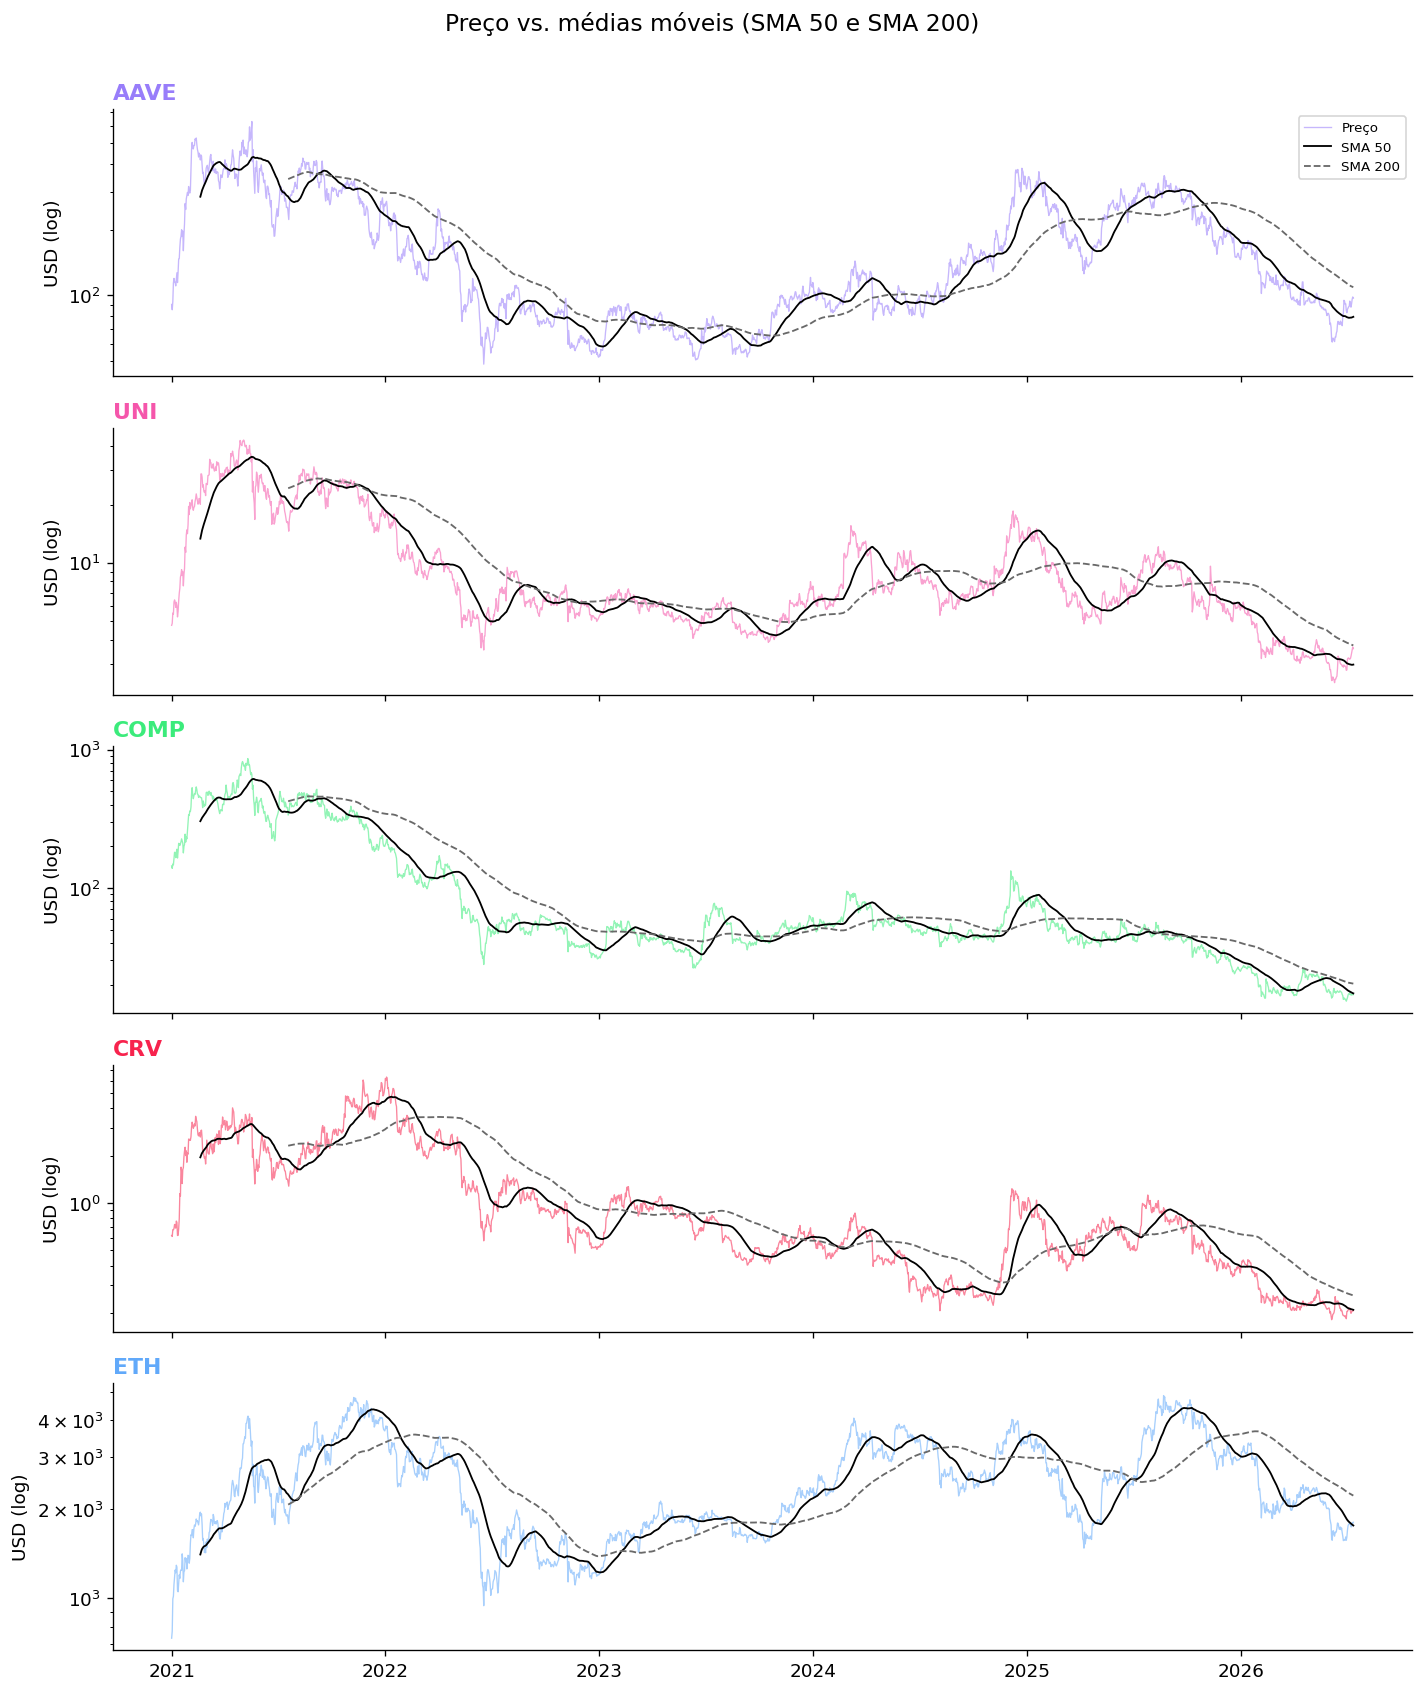

In [56]:
eda["sma_50"]  = eda.groupby("ticker")["close"].transform(lambda s: s.rolling(50).mean())
eda["sma_200"] = eda.groupby("ticker")["close"].transform(lambda s: s.rolling(200).mean())

fig, axes = plt.subplots(len(TOKENS), 1, figsize=(12, 14), sharex=True)

for ax, token in zip(axes, TOKENS):
    d = eda[eda["ticker"] == token]
    ax.plot(d["date"], d["close"],   color=PALETA[token], lw=0.8, alpha=0.55, label="Preço")
    ax.plot(d["date"], d["sma_50"],  color="black",  lw=1.1, label="SMA 50")
    ax.plot(d["date"], d["sma_200"], color="dimgray", lw=1.1, ls="--", label="SMA 200")
    ax.set_title(token, loc="left", fontweight="bold", color=PALETA[token])
    ax.set_yscale("log")
    ax.set_ylabel("USD (log)")
    if token == TOKENS[0]:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Preço vs. médias móveis (SMA 50 e SMA 200)", y=1.005, fontsize=14)
plt.tight_layout()
salvar_fig(fig, "medias_moveis")
plt.show()

### 6.6 Correlação de retornos entre tokens

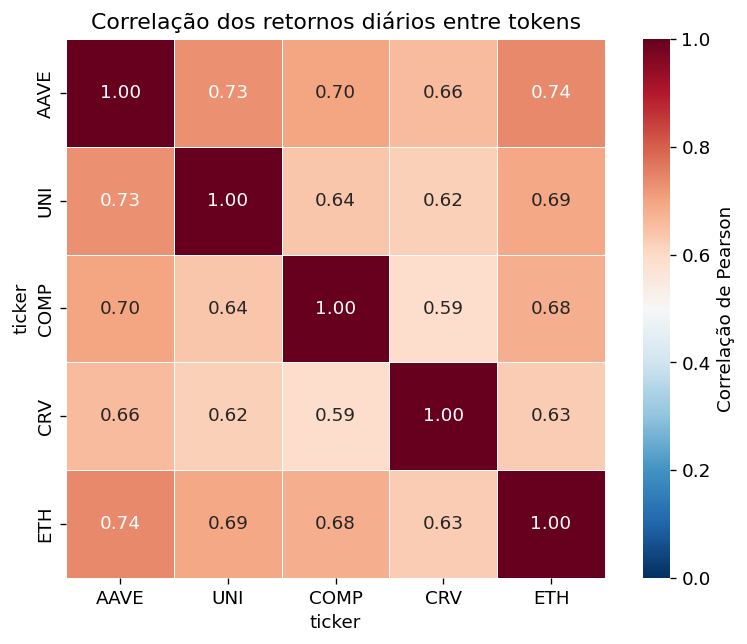

Correlação média entre pares: 0.67


In [57]:
# Pivot: colunas = tokens, valores = retorno diário
ret_wide = (df_unificado.assign(
                return_1d=df_unificado.groupby("ticker")["close"].pct_change())
            .pivot(index="date", columns="ticker", values="return_1d")
            [TOKENS])   # ordena as colunas como em TOKENS

corr = ret_wide.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Correlação de Pearson"}, ax=ax)
ax.set_title("Correlação dos retornos diários entre tokens")
plt.tight_layout()
salvar_fig(fig, "correlacao_tokens")
plt.show()

print(f"Correlação média entre pares: {corr.values[np.triu_indices(5, k=1)].mean():.2f}")

### 7. Engenharia de features

In [58]:
df = df_unificado.copy()
g = df.groupby("ticker")

# Retornos passados
df["return_1d"]  = g["close"].pct_change()
df["return_7d"]  = g["close"].pct_change(7)
df["return_30d"] = g["close"].pct_change(30)

# Volatilidade (desvio padrão dos retornos diários)
df["vol_7d"]  = g["return_1d"].transform(lambda s: s.rolling(7).std())
df["vol_30d"] = g["return_1d"].transform(lambda s: s.rolling(30).std())

# Médias móveis e distância do preço em relação a elas
df["ma_7"]  = g["close"].transform(lambda s: s.rolling(7).mean())
df["ma_30"] = g["close"].transform(lambda s: s.rolling(30).mean())
df["dist_ma30"] = df["close"] / df["ma_30"] - 1

# Volume relativo
df["vol_rel"] = df["volume"] / g["volume"].transform(lambda s: s.rolling(30).mean())

# Amplitude do dia
df["hl_range"] = (df["high"] - df["low"]) / df["close"]

# Target: retorno acumulado nos próximos N_FUTURO dias
df["future_return"] = g["close"].transform(lambda s: s.shift(-N_FUTURO) / s - 1)

# Remove linhas incompletas
antes = len(df)
df_features = df.dropna().reset_index(drop=True)
print(f"✔ Features criadas | {antes} → {len(df_features)} filas após dropna")

✔ Features criadas | 10095 → 9910 filas após dropna


### 7.1 Distribuição do target (future_return 7d) - EDA

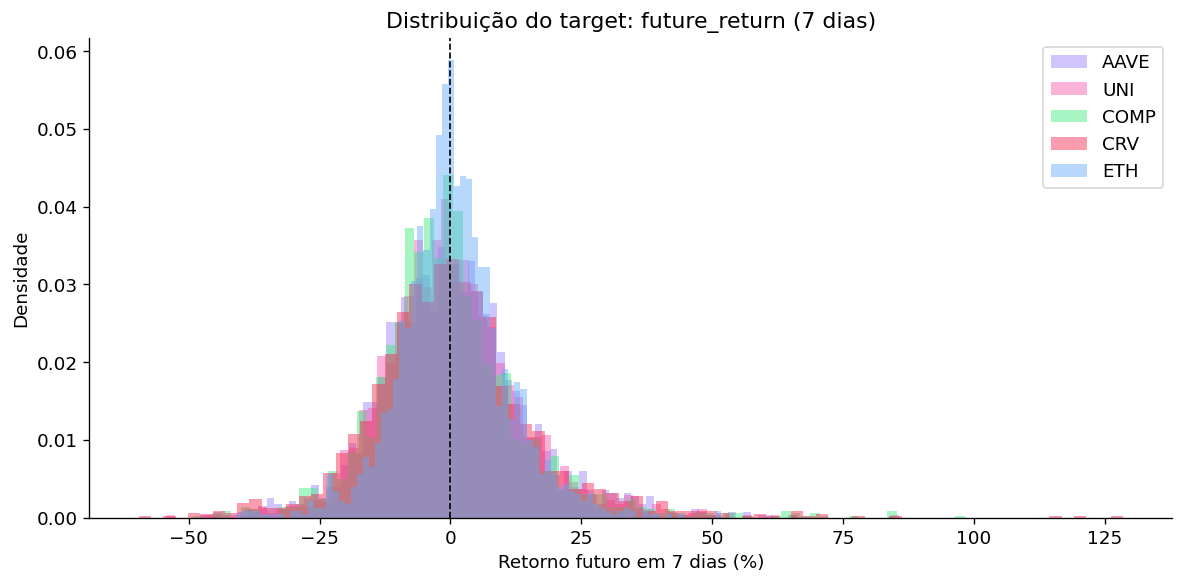

        mean    std    min     max
ticker                            
AAVE    0.49  14.10 -47.91   65.86
COMP   -0.12  14.58 -49.25   98.17
CRV     0.38  16.46 -59.54  128.48
ETH     0.59  10.36 -41.05   51.59
UNI     0.27  13.46 -54.26   85.65

% de semanas positivas: 47.8%


In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

for token in TOKENS:
    r = df_features.loc[df_features["ticker"] == token, "future_return"] * 100
    ax.hist(r, bins=80, alpha=0.45, color=PALETA[token], label=token, density=True)

ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel(f"Retorno futuro em {N_FUTURO} dias (%)")
ax.set_ylabel("Densidade")
ax.set_title(f"Distribuição do target: future_return ({N_FUTURO} dias)")
ax.legend()
plt.tight_layout()
salvar_fig(fig, "distribuicao_target")
plt.show()

print(df_features.groupby("ticker")["future_return"]
      .agg(["mean", "std", "min", "max"]).mul(100).round(2).to_string())
print(f"\n% de semanas positivas: {(df_features['future_return'] > 0).mean()*100:.1f}%")

### 7.3 Matriz de correlação entre features - EDA

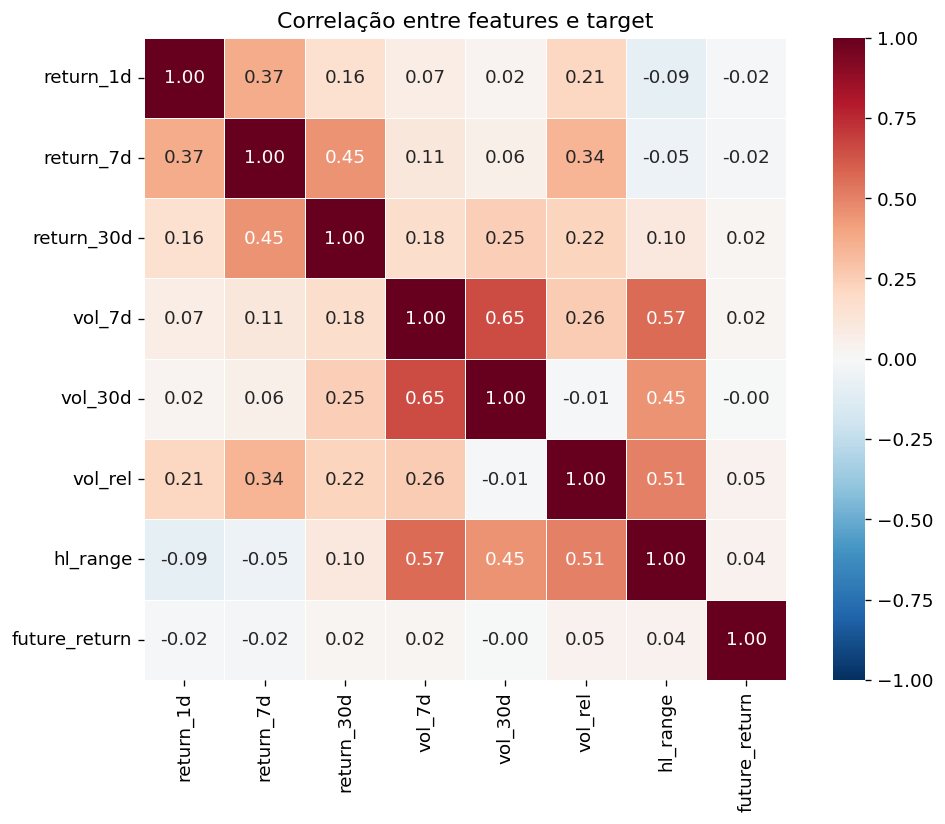

In [60]:
FEATURES = ["return_1d", "return_7d", "return_30d", "vol_7d", "vol_30d",
            "vol_rel", "hl_range"]

corr_feat = df_features[FEATURES + ["future_return"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_feat, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlação entre features e target")
plt.tight_layout()
salvar_fig(fig, "correlacao_features")
plt.show()

### 7.4 Diagnóstico de multicolinearidade: VIF

In [61]:
X_vif = df_features[FEATURES].dropna()
X_vif_s = StandardScaler().fit_transform(X_vif)   # padroniza antes do VIF

vif = pd.DataFrame({
    "feature": FEATURES,
    "VIF": [variance_inflation_factor(X_vif_s, i) for i in range(len(FEATURES))]
}).sort_values("VIF", ascending=False)

print(vif.round(2).to_string(index=False))

   feature  VIF
  hl_range 2.44
    vol_7d 2.18
   vol_30d 2.18
   vol_rel 2.05
 return_7d 1.63
return_30d 1.35
 return_1d 1.22


## 8. Modelagem
### Split temporal: 80% treino e 20% teste

In [62]:
data_corte = df_features["date"].quantile(0.80)

# Purga: remove do treino os últimos N_FUTURO dias antes do corte,
# pois o target dessas linhas "enxerga" datas que estão no teste
treino = df_features[df_features["date"] <= data_corte - pd.Timedelta(days=N_FUTURO)]
teste  = df_features[df_features["date"] >  data_corte]

X_treino, y_treino = treino[FEATURES], treino["future_return"]
X_teste,  y_teste  = teste[FEATURES],  teste["future_return"]

print(f"Corte temporal: {data_corte.date()}")
print(f"Treino: {len(treino)} obs | {treino['date'].min().date()} → {treino['date'].max().date()}")
print(f"Teste:  {len(teste)} obs | {teste['date'].min().date()} → {teste['date'].max().date()}")

Corte temporal: 2025-06-04
Treino: 7895 obs | 2021-01-31 → 2025-05-28
Teste:  1980 obs | 2025-06-05 → 2026-07-05


### Modelos: Baseline linear vs. Random Forest

In [63]:
# Regressão linear (com padronização)
scaler = StandardScaler()
X_treino_s = scaler.fit_transform(X_treino)
X_teste_s  = scaler.transform(X_teste)

lin = LinearRegression().fit(X_treino_s, y_treino)
pred_lin = lin.predict(X_teste_s)

# Random Forest (não precisa de padronização)
rf = RandomForestRegressor(n_estimators=300, max_depth=6,
                           min_samples_leaf=50, random_state=42, n_jobs=-1)
rf.fit(X_treino, y_treino)
pred_rf = rf.predict(X_teste)

# Baseline ingênuo: prever sempre a média do treino
pred_naive = np.full(len(y_teste), y_treino.mean())

print(f"{'Modelo':<20}{'R²':>8}{'MAE':>8}")
for nome, pred in [("Naive (média)", pred_naive),
                   ("Regressão Linear", pred_lin),
                   ("Random Forest", pred_rf)]:
    print(f"{nome:<20}{r2_score(y_teste, pred):>8.4f}{mean_absolute_error(y_teste, pred):>8.4f}")

Modelo                    R²     MAE
Naive (média)        -0.0188  0.0856
Regressão Linear     -0.0376  0.0864
Random Forest        -0.0562  0.0871


### Validação cruzada temporal (5 folds)

In [64]:
df_ord = df_features.sort_values("date").reset_index(drop=True)
X_all, y_all = df_ord[FEATURES], df_ord["future_return"]

tscv = TimeSeriesSplit(n_splits=5, gap=N_FUTURO)   # gap = purga automática

resultados = []
for i, (idx_tr, idx_te) in enumerate(tscv.split(X_all), 1):
    X_tr, X_te = X_all.iloc[idx_tr], X_all.iloc[idx_te]
    y_tr, y_te = y_all.iloc[idx_tr], y_all.iloc[idx_te]

    rf_cv = RandomForestRegressor(n_estimators=300, max_depth=6,
                                  min_samples_leaf=50, random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr)
    pred = rf_cv.predict(X_te)

    # Acerto direcional: % de vezes que o sinal da previsão = sinal do real
    acerto = (np.sign(pred) == np.sign(y_te)).mean() * 100

    periodo = f"{df_ord['date'].iloc[idx_te[0]].date()} → {df_ord['date'].iloc[idx_te[-1]].date()}"
    resultados.append({"fold": i, "período teste": periodo,
                       "R²": r2_score(y_te, pred),
                       "MAE": mean_absolute_error(y_te, pred),
                       "acerto direcional (%)": acerto})

res = pd.DataFrame(resultados).round(4)
display(res)
print(f"Média: R² = {res['R²'].mean():.4f} | acerto direcional = {res['acerto direcional (%)'].mean():.1f}%")

,fold,período teste,R²,MAE,acerto direcional (%)
0,1,2021-12-28 → 2022-11-23,-0.0675,0.1210,47.1230
1,2,2022-11-23 → 2023-10-19,-0.0584,0.0779,53.3010
2,3,2023-10-19 → 2024-09-13,-0.0086,0.0891,52.7559
3,4,2024-09-13 → 2025-08-09,-0.0520,0.1115,49.8486
4,5,2025-08-09 → 2026-07-05,-0.1110,0.0829,44.2156


Média: R² = -0.0595 | acerto direcional = 49.4%


### Comparação multimodelo sob CV temporal

In [65]:
modelos_cv = {
    "Ridge (α=1.0)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6,
                                           min_samples_leaf=50, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                                   max_depth=3, subsample=0.8, random_state=42),
}
tscv = TimeSeriesSplit(n_splits=5, gap=N_FUTURO)
for nome, m in modelos_cv.items():
    r2s, maes = [], []
    for idx_tr, idx_te in tscv.split(X_all):
        m.fit(X_all.iloc[idx_tr], y_all.iloc[idx_tr])
        pred = m.predict(X_all.iloc[idx_te])
        r2s.append(r2_score(y_all.iloc[idx_te], pred))
        maes.append(mean_absolute_error(y_all.iloc[idx_te], pred))
    print(f"{nome:<20} R² médio = {np.mean(r2s):+.4f} | MAE médio = {np.mean(maes):.4f}")

Ridge (α=1.0)        R² médio = -0.0530 | MAE médio = 0.0958
Random Forest        R² médio = -0.0595 | MAE médio = 0.0965
Gradient Boosting    R² médio = -0.1045 | MAE médio = 0.0993


### Ranking InfoFi por token

In [66]:
resultados_tok = []
for token in TOKENS:
    d = df_features[df_features["ticker"] == token].sort_values("date")
    corte = d["date"].quantile(0.80)
    tr = d[d["date"] <= corte - pd.Timedelta(days=N_FUTURO)]   # com purga
    te = d[d["date"] > corte]

    modelo = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                       max_depth=3, subsample=0.8, random_state=42)
    modelo.fit(tr[FEATURES], tr["future_return"])
    pred = modelo.predict(te[FEATURES])

    r2  = r2_score(te["future_return"], pred)
    ic, pval = spearmanr(pred, te["future_return"])            # IC fora da amostra
    acerto = (np.sign(pred) == np.sign(te["future_return"])).mean() * 100
    feat_top = pd.Series(modelo.feature_importances_, index=FEATURES).idxmax()

    # InfoFi Score: IC clipado em 0 - mede conteúdo informacional relativo
    score = max(ic, 0)

    resultados_tok.append({"Token": token, "R²": round(r2, 4),
                           "IC (Spearman)": round(ic, 4), "p-valor": round(pval, 4),
                           "Acerto dir. (%)": round(acerto, 1),
                           "Feature dominante": feat_top,
                           "InfoFi_Score": round(score, 4)})

df_infofi = (pd.DataFrame(resultados_tok)
             .sort_values("InfoFi_Score", ascending=False)
             .reset_index(drop=True))
df_infofi.index = df_infofi.index + 1
df_infofi.index.name = "Ranking"
display(df_infofi)

,Token,R²,IC (Spearman),p-valor,Acerto dir. (%),Feature dominante,InfoFi_Score
Ranking,,,,,,,
1,AAVE,-0.0089,0.1439,0.0041,53.4,vol_30d,0.1439
2,ETH,-0.0781,0.0864,0.0855,52.1,vol_30d,0.0864
3,CRV,-0.1175,0.0263,0.6011,55.2,vol_30d,0.0263
4,COMP,-0.4261,-0.0987,0.0494,42.1,vol_30d,0.0000
5,UNI,-0.1783,-0.1343,0.0074,45.3,vol_30d,0.0000


### Gráfico do ranking InfoFi

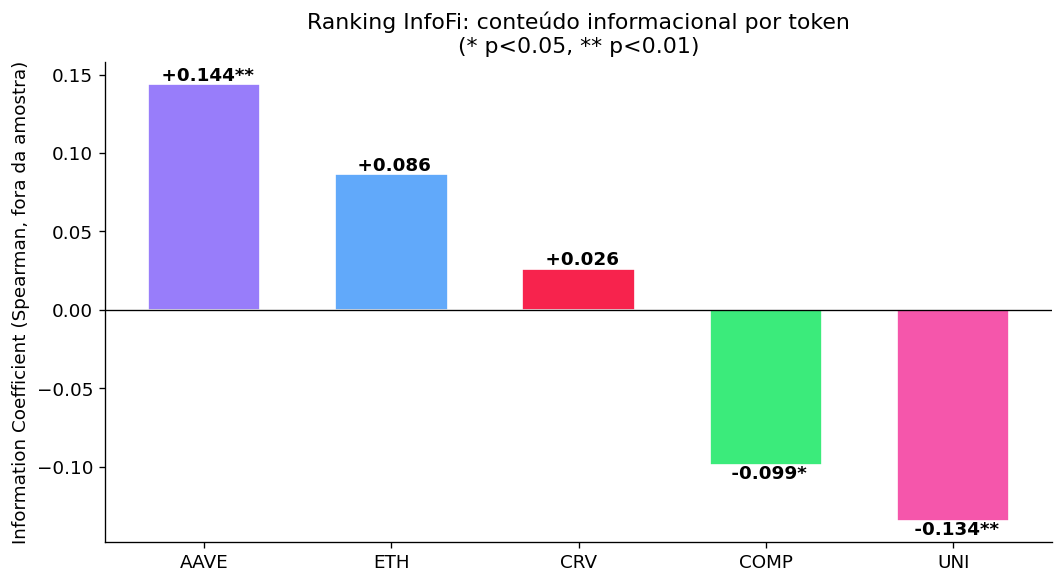

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = [PALETA[t] for t in df_infofi["Token"]]
bars = ax.bar(df_infofi["Token"], df_infofi["IC (Spearman)"], color=cores,
              edgecolor="white", width=0.6)
ax.axhline(0, color="black", lw=0.8)

# Marca significância estatística
for bar, (_, row) in zip(bars, df_infofi.iterrows()):
    sig = "**" if row["p-valor"] < 0.01 else ("*" if row["p-valor"] < 0.05 else "")
    va = "bottom" if row["IC (Spearman)"] >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, row["IC (Spearman)"],
            f' {row["IC (Spearman)"]:+.3f}{sig}', ha="center", va=va, fontweight="bold")

ax.set_ylabel("Information Coefficient (Spearman, fora da amostra)")
ax.set_title("Ranking InfoFi: conteúdo informacional por token\n(* p<0.05, ** p<0.01)")
plt.tight_layout()
salvar_fig(fig, "ranking_infofi")
plt.show()

### Verificação de robustez do IC sob dependência serial do alvo

In [68]:
rng = np.random.default_rng(42)
B = 2000

# 1) Previsões e retornos realizados por token (mesmo protocolo do ranking)
preds, reals = {}, {}
for token in TOKENS:
    d = df_features[df_features.ticker == token].sort_values("date")
    corte = d.date.quantile(0.80)
    tr = d[d.date <= corte - pd.Timedelta(days=N_FUTURO)]
    te = d[d.date > corte]
    m = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                  max_depth=3, subsample=0.8, random_state=42)
    m.fit(tr[FEATURES], tr.future_return)
    preds[token], reals[token] = m.predict(te[FEATURES]), te.future_return.values

n = len(preds[TOKENS[0]])

def blocos(size):
    """Índices de um bootstrap por blocos de comprimento N_FUTURO."""
    st = rng.integers(0, size - N_FUTURO, size=size // N_FUTURO)
    return np.concatenate([np.arange(s, s + N_FUTURO) for s in st])

# 2) IC em subamostras não sobrepostas + IC 95% por block bootstrap
for t in TOKENS:
    ics_sub = [spearmanr(preds[t][k::N_FUTURO], reals[t][k::N_FUTURO])[0]
               for k in range(N_FUTURO)]
    bs = [spearmanr(preds[t][i], reals[t][i])[0]
          for i in (blocos(n) for _ in range(B))]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    print(f"{t}: IC_sub={np.mean(ics_sub):+.4f} | IC95%=[{lo:+.4f},{hi:+.4f}]")

# 3) Diferença entre os extremos do ranking, com blocos pareados
diffs = []
for _ in range(B):
    i = blocos(n)
    diffs.append(spearmanr(preds["AAVE"][i], reals["AAVE"][i])[0]
                 - spearmanr(preds["UNI"][i],  reals["UNI"][i])[0])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"AAVE-UNI = {np.mean(diffs):+.4f} | IC95%=[{lo:+.4f},{hi:+.4f}] "
      f"| p1={np.mean(np.array(diffs) <= 0):.4f}")

# 4) Teste global de heterogeneidade: amplitude dos cinco ICs sob permutação
#    por deslocamento circular (rompe o alinhamento previsão-retorno,
#    preserva a dependência serial de ambas as séries)
obs = {t: spearmanr(preds[t], reals[t])[0] for t in TOKENS}
obs_range = max(obs.values()) - min(obs.values())

for modo in ("independente", "compartilhado"):
    null = []
    for _ in range(B):
        k = rng.integers(N_FUTURO, n - N_FUTURO)          # compartilhado
        ics = [spearmanr(preds[t],
                         np.roll(reals[t],
                                 k if modo == "compartilhado"
                                 else rng.integers(N_FUTURO, n - N_FUTURO)))[0]
               for t in TOKENS]
        null.append(max(ics) - min(ics))
    print(f"amplitude={obs_range:.4f} | deslocamento {modo}: "
          f"p={np.mean(np.array(null) >= obs_range):.4f}")

AAVE: IC_sub=+0.1533 | IC95%=[-0.0378,+0.3043]
UNI: IC_sub=-0.1166 | IC95%=[-0.2863,+0.0322]
COMP: IC_sub=-0.0975 | IC95%=[-0.2553,+0.0302]
CRV: IC_sub=+0.0302 | IC95%=[-0.1458,+0.1838]
ETH: IC_sub=+0.0825 | IC95%=[-0.0921,+0.2632]
AAVE-UNI = +0.2702 | IC95%=[+0.0215,+0.5252] | p1=0.0185
amplitude=0.2782 | deslocamento independente: p=0.3520
amplitude=0.2782 | deslocamento compartilhado: p=0.3005


## 9. SHAP: explicabilidade do Random Forest global

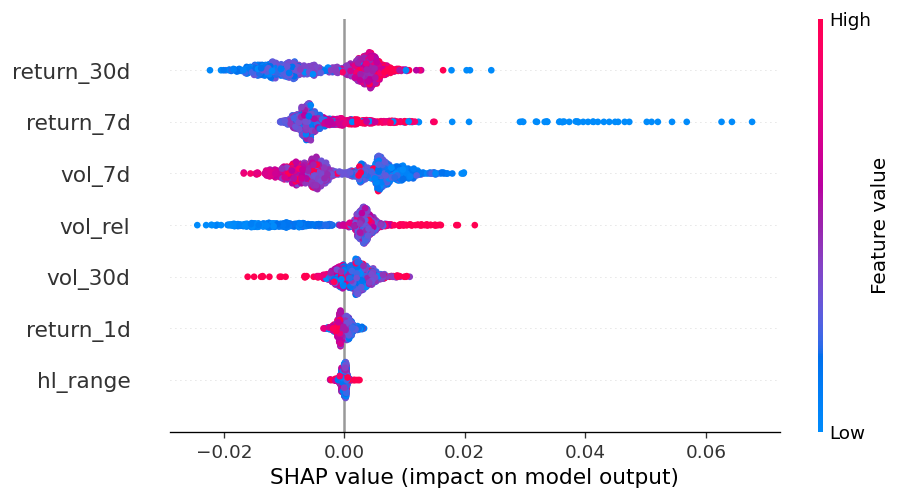

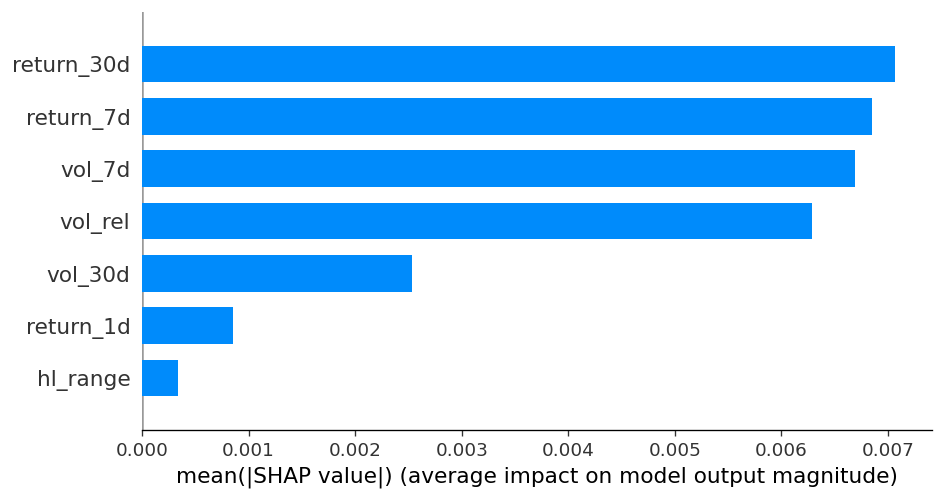

In [69]:
explainer = shap.TreeExplainer(rf)

X_amostra = X_teste.sample(min(1000, len(X_teste)), random_state=42)
shap_values = explainer.shap_values(X_amostra)

# Beeswarm: direção e magnitude do efeito de cada feature
shap.summary_plot(shap_values, X_amostra, show=False)
fig = plt.gcf()
salvar_fig(fig, "shap_beeswarm_global")
plt.show()

# Barras: importância média absoluta
shap.summary_plot(shap_values, X_amostra, plot_type="bar", show=False)
fig = plt.gcf()
salvar_fig(fig, "shap_importancia_global")
plt.show()

### 9.1 SHAP do modelo de AAVE (único com IC significativo)

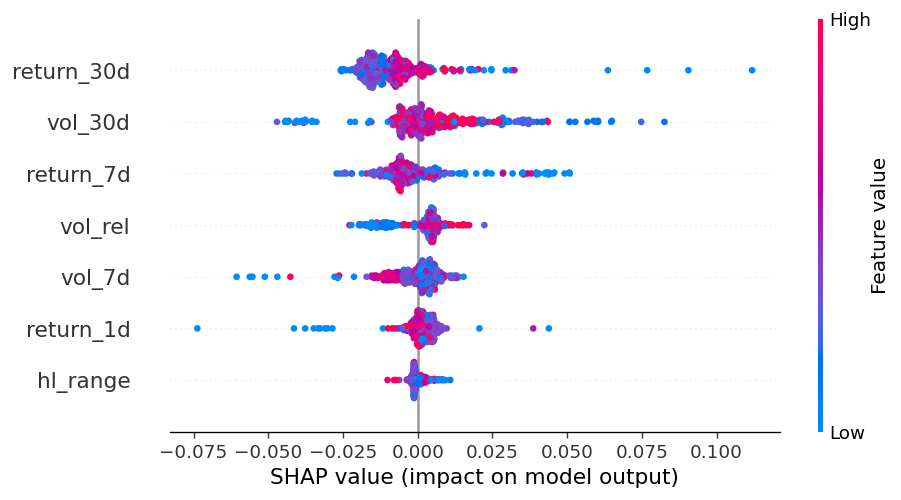

In [70]:
d = df_features[df_features["ticker"] == "AAVE"].sort_values("date")
corte = d["date"].quantile(0.80)
tr = d[d["date"] <= corte - pd.Timedelta(days=N_FUTURO)]
te = d[d["date"] > corte]

gbm_aave = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                     max_depth=3, subsample=0.8, random_state=42)
gbm_aave.fit(tr[FEATURES], tr["future_return"])

explainer_aave = shap.TreeExplainer(gbm_aave)
shap_aave = explainer_aave.shap_values(te[FEATURES])

shap.summary_plot(shap_aave, te[FEATURES], show=False)
fig = plt.gcf()
salvar_fig(fig, "shap_beeswarm_aave")
plt.show()

### Previsões vs. valores reais (AAVE, fora da amostra)

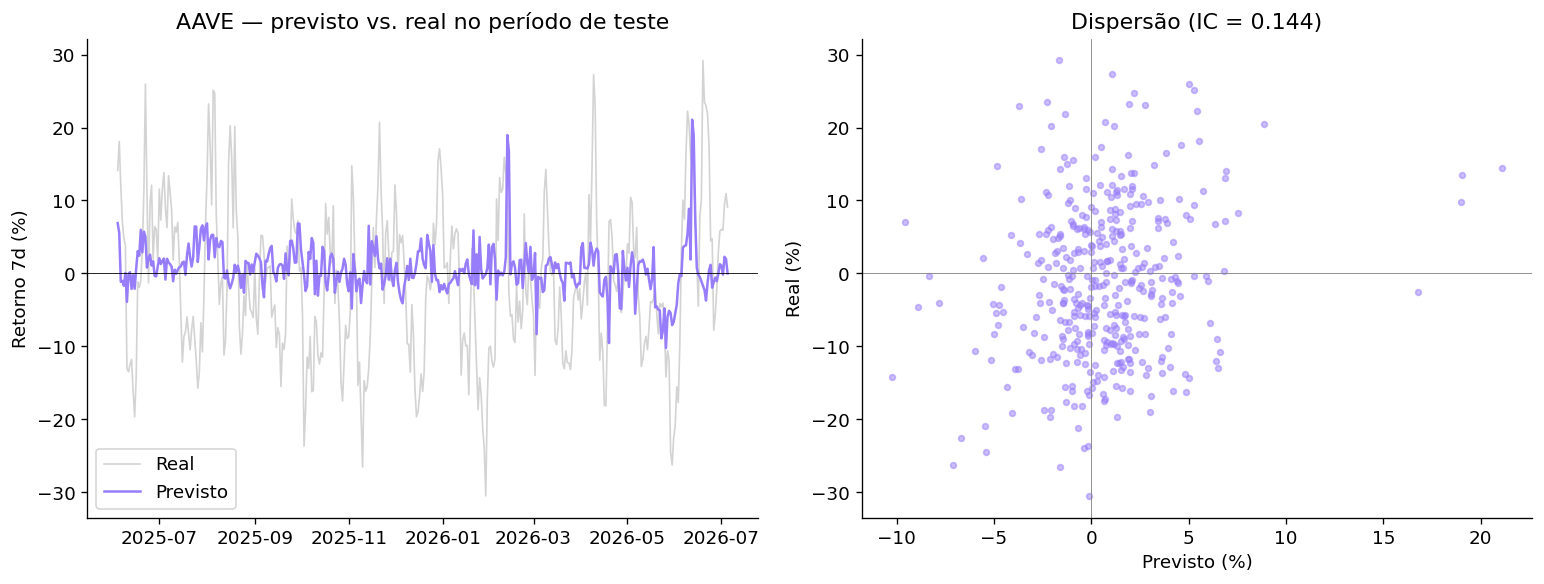

In [71]:
pred_te = gbm_aave.predict(te[FEATURES])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Série temporal
ax1.plot(te["date"], te["future_return"]*100, color="lightgray", lw=1, label="Real")
ax1.plot(te["date"], pred_te*100, color=PALETA["AAVE"], lw=1.5, label="Previsto")
ax1.axhline(0, color="black", lw=0.5)
ax1.set_ylabel("Retorno 7d (%)")
ax1.set_title("AAVE — previsto vs. real no período de teste")
ax1.legend()

# Dispersão
ax2.scatter(pred_te*100, te["future_return"]*100, s=12, alpha=0.5, color=PALETA["AAVE"])
ax2.axhline(0, color="gray", lw=0.5); ax2.axvline(0, color="gray", lw=0.5)
ax2.set_xlabel("Previsto (%)"); ax2.set_ylabel("Real (%)")
ax2.set_title(f"Dispersão (IC = {spearmanr(pred_te, te['future_return'])[0]:.3f})")

plt.tight_layout()
salvar_fig(fig, "pred_vs_real_aave")
plt.show()

## 10. Conclusões

**Pipeline de dados.** Foram coletados preços diários de 5 tokens (AAVE, UNI, COMP, CRV, ETH, 2021–2026) combinando Kaggle (fonte primária) e Yahoo Finance (volume, dias recentes e uma lacuna de 49 dias detectada na fonte primária), com preenchimento forward-fill para evitar viés de antecipação (look-ahead bias).

**Análise exploratória.** Os retornos diários apresentam caudas pesadas (curtose 3,4–10,8) e não-normalidade, justificando modelos não paramétricos. A correlação média entre tokens é de 0,67, o fator de mercado domina a dinâmica individual. Os drawdowns máximos variaram de -80% (ETH) a -98% (COMP).

**Modelagem.** Após diagnóstico de multicolinearidade (VIF), 7 features técnicas alimentaram modelos Naive, Linear e Random Forest com validação cruzada temporal (5 folds, com purga). O R² foi negativo em todos os folds (média -0,06) e o acerto direcional médio foi de 49,4%, indistinguível do acaso. O resultado é consistente com a Hipótese dos Mercados Eficientes: sinais técnicos públicos não contêm informação explorável para o horizonte de 7 dias. **H1 refutada.**

**Ranking InfoFi.** Medindo o conteúdo informacional relativo via Information Coefficient fora da amostra, o ranking nominal sugere heterogeneidade entre tokens: AAVE (IC = +0,144) e UNI (IC = -0,134), ambos com p < 0,01 e sobreviventes à correção de Bonferroni, com contraste de sinal que indicaria instabilidade de regime na relação sinal→retorno.

**Verificação de robustez (contribuição central).** O alvo usa janelas móveis de 7 dias, de modo que observações consecutivas compartilham 6 dos 7 dias do retorno futuro: o número efetivo de observações independentes é ≈ 57, não 396, e os p-valores nominais acima subestimam a incerteza em cerca de uma ordem de magnitude. Sob block bootstrap, os IC 95% dos cinco tokens contêm o zero (AAVE, [-0,038; +0,304]; UNI, [-0,286; +0,032]), embora as estimativas pontuais sejam estáveis em subamostras não sobrepostas. A diferença entre os extremos do ranking exclui o zero (+0,278; IC 95% [+0,022; +0,525]), mas o par foi selecionado post hoc; o teste global de dispersão, amplitude dos cinco ICs sob permutação por deslocamento circular, um único teste sem comparações múltiplas, não rejeita, nas duas variantes testadas (p = 0,349 com deslocamentos independentes; p = 0,307 com deslocamento compartilhado, que preserva a correlação cruzada dos erros e produz nulo mais
estreito). **H2 não sustentada.** A ausência de rejeição é inconclusiva por insuficiência amostral, não evidência de homogeneidade. Sob inferência corrigida o InfoFi Score dos cinco datasets é nulo: a métrica recusou-se a precificar sinais que não sobrevivem à verificação, exatamente como definido na Seção 4.5.

**Explicabilidade (SHAP).** O modelo global aprendeu reversão de curto prazo e aversão à volatilidade; o modelo de AAVE exibe relação invertida com a volatilidade de 30 dias (turbulência precede recuperação, comportamento tipo prêmio de risco). Como nenhum modelo apresenta conteúdo informacional validado fora da amostra, essas relações descrevem as hipóteses que os modelos formaram, não propriedades estabelecidas do mercado.

**Limitações e trabalhos futuros.** Além da dependência serial tratada acima, o ranking deriva de um único corte temporal (janelas móveis aumentariam a robustez) e as features são exclusivamente técnicas, categoria pública e trivialmente replicável cujo valor marginal a teoria prevê nulo. A extensão prioritária é incorporar dados on-chain (TVL, fluxos entre carteiras, concentração de holders, atividade de contratos), onde o valor informacional marginal tende a residir, e formalizar o p-valor por reamostragem em blocos como parte da definição do InfoFi Score.